In [1]:
#In case you want to run the code:
#imports
import pandas as pd
import geopandas as gpd

#required import for geopandas (as we are using it), that was not auto installed as a dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO
from shapely import wkt, distance, LineString

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
#import leafmap.foliumap as leafmap

# numpy
import numpy as np

# Feature Engineering
from sklearn.preprocessing import StandardScaler

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Model requirements
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


# Model validation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc, precision_score, recall_score

Sections:
Introduction (data origin, feature descriptions, and motivating question(s))

Exploratory Data Analysis (Graphs and Summary Statistics and what you can learn from it)

Machine Learning (At least two methods relevant to the data)

Summary and Conclusions

Limitations and Recommendations for future work.

## Introduction

#### Data Origin
This dataset was retrieved from the New York Open Data Program,
an open-source repository for New York State’s publicly available datasets.
It contains 2024 Metropolitan Transportation Authority (MTA) ridership data
estimated and collected from MetroCard swipe and contactless MTA payment
systems (OMNY). The original dataset represents aggregated ridership from
each origin-destination combination along with the month, hour, and day of
the week.

#### Feature Descriptions
**Variables:**
- Timestamp (Year, Month, Hour, Day of Week)  |  *Datetime*
- Origin / Destination Station ID + Name  |  *Number/Text*
- Station Latitude / Longitude Coordinates  |  *Number*
- Estimated Average Ridership  |  *Number*
- Origin Point (Geospatial)  |  *Point Feature*

#### Motivating Questions
Within this dataset, we are most interested in the sum_estimated_average_ridership column.
This column represents the average estimated number of passengers aggregated by origin station,
month, hour, and day of the week. To begin, we want to examine patterns within the ridership variable
related to month, time or day, day of the week, and origin structure. For example, do subway stations
cluster into distinct communities? Do seasons contribute to average ridership? Which stations have the
largest demand?

Overall, however, our main question is *can we accurately forcast station ridership?*


## Exploratory Data Analysis

#### Cleaning the Data
For this project, we had two datasets: origin_data (aggregated average estimated ridership
by station, month, day of the week, and hour) and origin_destination (included sum average estimated ridership and distance for each pair of origin and destination stations)

##### origin_data
The data cleaning of origin_data was fairly straight forward; all that needed to be done was
to organize the rows, standardize the column names-to remove spaces and capitalization-and
transform the ridership column into numeric data (removing the comma) for easier and better analysis.

In [3]:
#Reading in the data
url = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/refs/heads/main/Data/Raw/origin_ridership_time_series.csv"
origin_raw = pd.read_csv(StringIO(requests.get(url, verify=False).text))

# Organize rows by station, month, day of week, and hour of day
origin = (
    origin_raw
    .sort_values(by=["Origin Station Complex ID", "Month", "Day of Week", "Hour of Day"])
)

# Standardize column names
origin.columns = origin.columns.str.strip().str.lower().str.replace(" ", "_")

# Turn the ridership column to numeric (remove commas)
origin['sum_estimated_average_ridership'] = (
    pd.to_numeric(origin_raw['sum_estimated_average_ridership'].str.replace(',', ''))
)

C:\Users\lilas\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


##### origin_destination
For origin_destination, we also had to standardize column names and transform the ridership column to numeric data. Similarly, however, we turned the 'origin_point' and 'destination_point' variables into geometry objects and added them to a GeoDataFrame so that they can be effectively graphed. In this GeoDataFrame, we also added the log(ridership), the distance between each station, and a new ridership per kilometer variable.

In [4]:
#Reading in the data
url = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/refs/heads/main/Data/Raw/origin_destination_flows.csv"
od_flows_raw = pd.read_csv(StringIO(requests.get(url, verify=False).text))
od_flows = od_flows_raw.copy()

# Standardize column names
od_flows.columns = od_flows_raw.columns.str.strip().str.lower().str.replace(" ", "_")

# Turn the ridership column to numeric (remove commas)
od_flows['sum_estimated_average_ridership'] = (
    pd.to_numeric(od_flows_raw['sum_estimated_average_ridership'].str.replace(',', ''))
)

#Turn the Point Data into a Geometry Type
od_flows["origin_point"] = od_flows["origin_point"].apply(wkt.loads)
od_flows["destination_point"] = od_flows["destination_point"].apply(wkt.loads)

#Turn into a GroDataFrame for mapping
od_flows["geometry"] = od_flows.apply(
    lambda row: LineString([
        row["origin_point"],
        row["destination_point"]
    ]),
    axis=1
)

od_flows_geo = gpd.GeoDataFrame(
    od_flows,
    geometry="geometry",
    crs="EPSG:4326"
)

#Calculate distance between two stations
od_projected = od_flows_geo.to_crs("EPSG:32618")

od_flows_geo["distance_meters"] = od_projected.length
od_flows_geo["distance_km"] = od_flows_geo["distance_meters"] / 1000

#Log of ridership (skewed)
od_flows_geo["log_ridership"] = np.log1p(od_flows_geo["sum_estimated_average_ridership"])

#Riders per kilometer
od_flows_geo["riders_per_km"] = (
    od_flows_geo["sum_estimated_average_ridership"] /
    od_flows_geo["distance_km"]
)

od_flows_geo["geometry"] = od_flows_geo.apply(
    lambda row: LineString([row["origin_point"], row["destination_point"]]), axis=1
)

od_flows_geo["origin_point_wkt"] = od_flows_geo["origin_point"].apply(lambda g: g.wkt)
od_flows_geo["destination_point_wkt"] = od_flows_geo["destination_point"].apply(lambda g: g.wkt)

od_flows_geo.drop(columns=["origin_point", "destination_point"]) \
    .set_geometry("geometry") \
    .to_parquet("origin_destination_flows_CLEAN.parquet")

C:\Users\lilas\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'raw.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


#### Summary Statistics

##### Table 1
PUT TABLE 1 HERE OR SMTH ILL GET BACK TO THIS LATER

##### Data Visualizations
Firstly, we wanted to visualize the data in order to see if there were any patterns in ridership
for day of the week, hour of the day, month of the year, and season

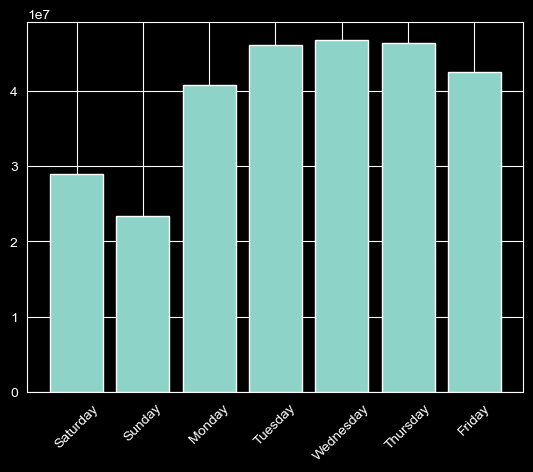

Day of the week: total ridership
Saturday: 29009734.824400004
Sunday: 23397423.0419
Monday: 40750677.3636
Tuesday: 46106946.1171
Wednesday: 46749949.310100004
Thursday: 46325195.726799995
Friday: 42555436.7229


In [5]:
# origin day of week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
total_ridership_per_day_of_week = [origin[origin['day_of_week'] == i]['sum_estimated_average_ridership'].sum() for i in day_of_week]
plt.bar(day_of_week, total_ridership_per_day_of_week)
plt.tick_params(axis='x', labelrotation=45)
# plt.ticklabel_format(style='plain') #for some reason this is only causing an error for this graph
plt.show()
print('Day of the week: total ridership')
for i in range(7):
    print(f'{day_of_week[i]}: {total_ridership_per_day_of_week[i]}')

Unsurprisingly, it appears that there is a higher average estimated ridership on weekdays than
there is on weekends. This is most likely because one of the subway's primary purposes is for
commuters, who would not be utilizing it on weekends. There is also a slight increase in
ridership on Tuesday, Wednesday, and Thursday. As this is 2024 data, many workers have now started
to split their time between in-person and remote work. We hypothesize that this increase may be
due to more workers choosing to go in-person on Tuesday, Wednesday, or Thursday rather than
Monday or Friday

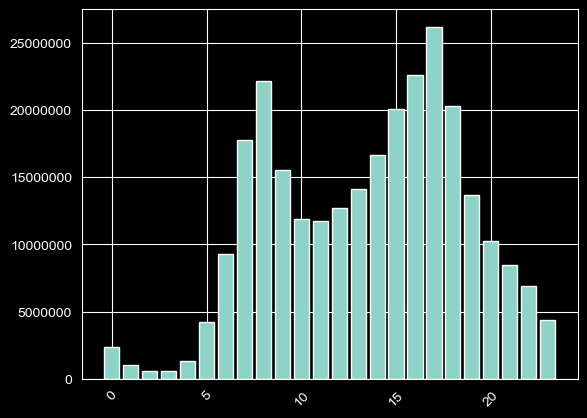

hour of the day: total ridership
0: 2355952.4046
1: 1016291.5595
2: 609685.6535
3: 587057.7875999999
4: 1326038.5767
5: 4238283.6273
6: 9272181.559999999
7: 17772294.2271
8: 22146316.1456
9: 15563042.169400001
10: 11917519.1109
11: 11710357.1202
12: 12744275.600900002
13: 14148107.2139
14: 16629629.3381
15: 20079622.951
16: 22617136.205799997
17: 26183460.9067
18: 20315118.98
19: 13689476.8277
20: 10242757.240699999
21: 8457048.3487
22: 6893768.514900001
23: 4379941.036


In [6]:
# origin hour of day
hour_of_day = origin['hour_of_day'].unique()
total_ridership_per_hour_of_day = [origin[origin['hour_of_day'] == i]['sum_estimated_average_ridership'].sum() for i in hour_of_day]
plt.bar(hour_of_day, total_ridership_per_hour_of_day)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('hour of the day: total ridership')
for i in range(len(hour_of_day)):
    print(f'{hour_of_day[i]}: {total_ridership_per_hour_of_day[i]}')

This graph shows a commuting trend as well. Ridership appears to peak at approximately 8 am and
5 pm. This falls in line with the average workday being from 9-5 with workers having to leave
before 9 in order to get to their workplace in time.

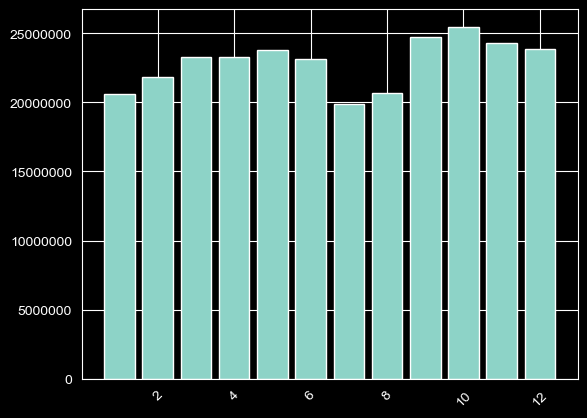

month of the year: total ridership
1: 20640117.3487
2: 21858037.6738
3: 23312621.7179
4: 23260391.0992
5: 23755413.8423
6: 23114608.935900003
7: 19875121.7932
8: 20686265.5928
9: 24742325.3384
10: 25464468.3014
11: 24320913.061899997
12: 23865078.4013


In [7]:
# origin month of year
month = origin['month'].unique()
total_ridership_per_month = [origin[origin['month'] == i]['sum_estimated_average_ridership'].sum() for i in month]
plt.bar(month, total_ridership_per_month)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('month of the year: total ridership')
for i in range(len(month)):
    print(f'{month[i]}: {total_ridership_per_month[i]}')

Average estimated ridership appears to decrease at two time periods: November-February and July-August. These two time periods also correspond with the holiday season as well as summer,
which is notably when most people tend to take time off of work. While the winter decrease in
ridership goes longer than we expected, both of these decreases are logical.